In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# VGG16 structure
def build_vgg16(input_shape=(224, 224, 3), num_classes=1):
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x)

    # Block 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x)

    # Block 3
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)

    # Block 4
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool')(x)

    # Block 5
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool')(x)

    # Classification
    x = Flatten(name='flatten')(x)
    x = Dense(4096, activation='relu', name='fc1')(x) 
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu', name='fc2')(x) 
    x = Dropout(0.5)(x)

    activation = 'sigmoid'
    outputs = Dense(num_classes, activation=activation)(x)

    return Model(inputs, outputs)

In [ ]:
# Path configuration
# IMPORTANT: Adjust this path if running locally
base_dir = '/content/drive/MyDrive/zellige Dataset/moroccan-zellige' # Adjust your path

if not os.path.exists(base_dir):
     print(f"Error: Base directory not found at {base_dir}")
     print("Please ensure the path is correct for your environment.")
     exit()

train_dir = os.path.join(base_dir, 'train') # train folder 
validation_dir = os.path.join(base_dir, 'validation') # validation folder
test_dir = os.path.join(base_dir, 'test') # test folder

In [ ]:
# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
# batch size
BATCH_SIZE = 8 

# Rescaling 
train_datagen = ImageDataGenerator(
    rescale=1./255, #<-- normalizing pixels 
    rotation_range=20,     
    width_shift_range=0.2, 
    height_shift_range=0.2,
    shear_range=0.2,      
    zoom_range=0.2,        
    horizontal_flip=True,  
    fill_mode='nearest'    
)

valid_datagen = ImageDataGenerator(rescale=1./255) 
test_datagen = ImageDataGenerator(rescale=1./255)  

# Data Generators 
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary', 
    shuffle=True
)

validation_generator = valid_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Typically no need to shuffle validation data 
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1,        # Process one image at a time for evaluation
    class_mode='binary',
    shuffle=False       
)

Found 1102 images belonging to 2 classes.
Found 229 images belonging to 2 classes.
Found 229 images belonging to 2 classes.


In [ ]:
# Verify class indices 
print("Class Indices (Train):", train_generator.class_indices)
print("Class Indices (Validation):", validation_generator.class_indices)
print("Class Indices (Test):", test_generator.class_indices)

Class Indices (Train): {'false': 0, 'true': 1}
Class Indices (Validation): {'false': 0, 'true': 1}
Class Indices (Test): {'false': 0, 'true': 1}



--- Displaying Sample Images from Shuffled Training Generator ---


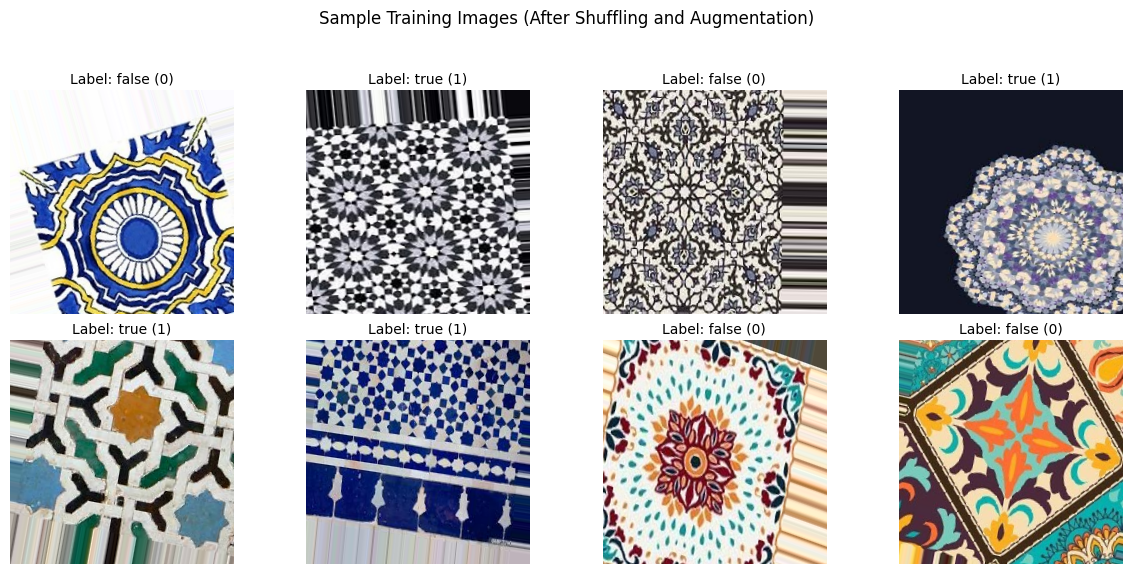

In [ ]:
#  Show image samples after shuffling from Training Data
print("\n--- Displaying Sample Images from Shuffled Training Generator ---")
# Get a batch of images and labels
images, labels = next(train_generator)

class_names_display = {v: k for k, v in train_generator.class_indices.items()}

num_to_show = min(len(images), BATCH_SIZE) 

plt.figure(figsize=(12, 6)) 
for i in range(num_to_show):
   
    img_display = (images[i] * 255).astype(np.uint8)
    label_index = int(labels[i])
    label_name = class_names_display[label_index]

    plt.subplot(2, (num_to_show + 1) // 2, i + 1)
    plt.imshow(img_display)
    plt.title(f"Label: {label_name} ({label_index})", fontsize=10)
    plt.axis('off')

plt.suptitle("Sample Training Images (After Shuffling and Augmentation)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

In [ ]:
# Compile model
model = build_vgg16(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=1) 

model.compile(optimizer=Adam(learning_rate=1e-5), # learning_rate = 0.00001  
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         4,09

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 134,264,641 (512.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Class Weights (Optional but recommended for imbalance)
class_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("\nCalculated Class Weights:", class_weight_dict)


Calculated Class Weights: {0: np.float64(1.3604938271604938), 1: np.float64(0.7905308464849354)}



Training Steps per Epoch: 137
Validation Steps per Epoch: 28
Training for 100 epochs...
Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 40s 234ms/step - accuracy: 0.4690 - loss: 0.6945 - val_accuracy: 0.3839 - val_loss: 0.6948
Epoch 2/100
  1/137 ━━━━━━━━━━━━━━━━━━━━ 24s 182ms/step - accuracy: 0.1250 - loss: 0.6023

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1250 - loss: 0.6023 - val_accuracy: 0.3839 - val_loss: 0.6945
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 27s 195ms/step - accuracy: 0.5310 - loss: 0.6795 - val_accuracy: 0.6161 - val_loss: 0.6441
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6250 - loss: 0.7382 - val_accuracy: 0.6429 - val_loss: 0.6618
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.6502 - loss: 0.6451 - val_accuracy: 0.6696 - val_loss: 0.5876
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7500 - loss: 0.5790 - val_accuracy: 0.6786 - val_loss: 0.5841
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 37s 198ms/step - accuracy: 0.7101 - loss: 0.5618 - val_accuracy: 0.6920 - val_loss: 0.5801
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7500 - loss: 0.6606 - val_accuracy: 0.6875 - val_loss: 0.5807
Epoch 9/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 41s 299ms/step - accuracy: 0.7401 - loss: 0.5382 - val_

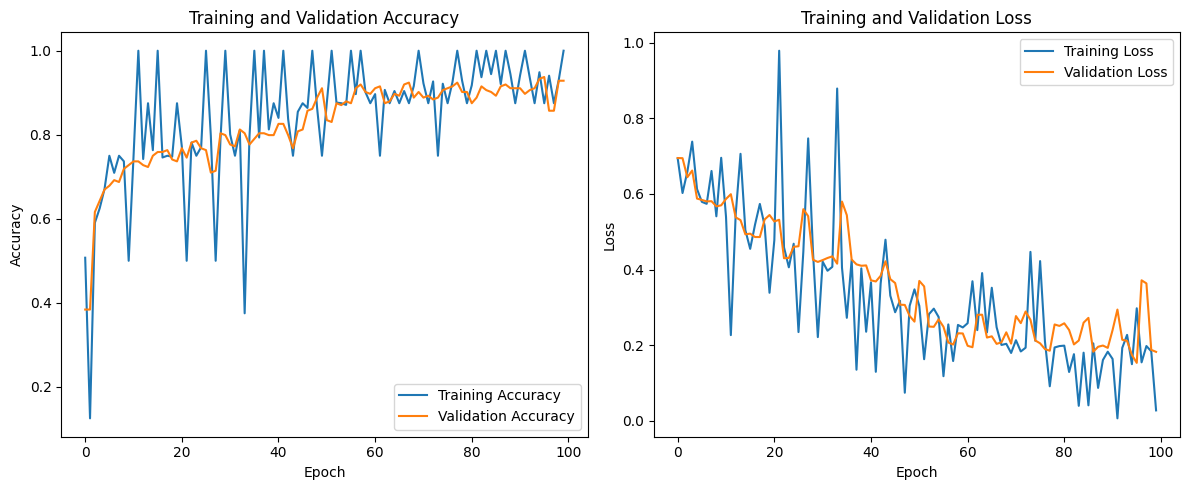

In [ ]:
# Training Process
EPOCHS = 100 # epochs = 100 Recommanded 

train_steps = train_generator.samples // BATCH_SIZE
if train_steps == 0: train_steps = 1 

validation_steps = validation_generator.samples // BATCH_SIZE
if validation_steps == 0: validation_steps = 1


print(f"\nTraining Steps per Epoch: {train_steps}")
print(f"Validation Steps per Epoch: {validation_steps}")
print(f"Training for {EPOCHS} epochs...")

history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    class_weight=class_weight_dict
)
# Plot Training History 
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc)) 

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')


    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

print("\n--- Plotting Training History ---")
plot_history(history)


--- Evaluating Model on Test Data ---
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

Classification Report (Test Set):
              precision    recall  f1-score   support

       false       0.84      0.93      0.88        86
        true       0.96      0.90      0.92       143

    accuracy                           0.91       229
   macro avg       0.90      0.91      0.90       229
weighted avg       0.91      0.91      0.91       229

Confusion Matrix (Test Set):


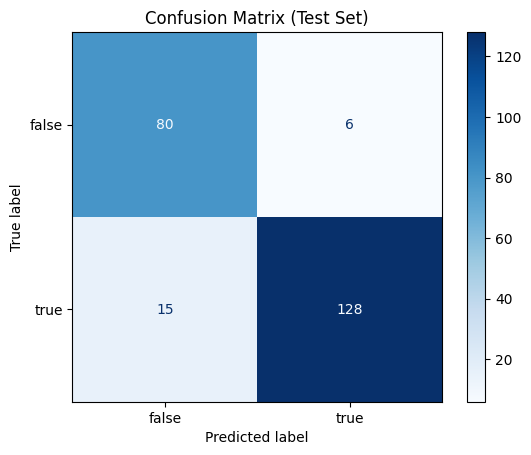


Manual Metrics Calculation (Test Set):
Accuracy: 0.9083
Precision (for 'true'): 0.9552
Recall (Sensitivity for 'true'): 0.8951
Specificity (for 'false'): 0.9302
F1-Score (for 'true'): 0.9242


(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32),
 array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
# Evaluation Function 
def evaluate_model(model, test_generator):
    print("\n--- Evaluating Model on Test Data ---")
    test_generator.reset()
    preds_proba = model.predict(test_generator, steps=test_generator.samples, verbose=1)
    pred_labels = (preds_proba > 0.5).astype(int).flatten()

    true_labels = test_generator.classes

    if len(pred_labels) != len(true_labels):
        print(f"Warning: Mismatch in prediction ({len(pred_labels)}) and label ({len(true_labels)}) counts!")
        print(f"Adjusting true labels count from {len(true_labels)} to {len(pred_labels)}")
        true_labels = true_labels[:len(pred_labels)] 

    print("\nClassification Report (Test Set):")
    target_names = [k for k, v in sorted(test_generator.class_indices.items(), key=lambda item: item[1])]
    print(classification_report(true_labels, pred_labels, target_names=target_names))

    # Confusion Matrix
    print("Confusion Matrix (Test Set):")
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names) 
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # Extract TP, TN, FP, FN for manual calculation verification 
    try:
        TN, FP, FN, TP = cm.ravel()
        accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0 
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        print(f"\nManual Metrics Calculation (Test Set):")
        print(f"Accuracy: {accuracy:.4f}")
        positive_class_name = target_names[1] if len(target_names)>1 else 'Class 1' # class 1 --> true
        negative_class_name = target_names[0] if len(target_names)>0 else 'Class 0' # class 0 --> false 
        print(f"Precision (for '{positive_class_name}'): {precision:.4f}")
        print(f"Recall (Sensitivity for '{positive_class_name}'): {recall:.4f}")
        print(f"Specificity (for '{negative_class_name}'): {specificity:.4f}")
        print(f"F1-Score (for '{positive_class_name}'): {f1_score:.4f}")
    except ValueError:
        print("Could not unpack CM values (TN, FP, FN, TP). Check matrix shape or if only one class was predicted.")
        print(f"Confusion Matrix shape: {cm.shape}")

    return true_labels, pred_labels, preds_proba 

evaluate_model(model, test_generator)


--- Evaluating Model on Test Data ---
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

Classification Report (Test Set):
              precision    recall  f1-score   support

       false       0.84      0.93      0.88        86
        true       0.96      0.90      0.92       143

    accuracy                           0.91       229
   macro avg       0.90      0.91      0.90       229
weighted avg       0.91      0.91      0.91       229

Confusion Matrix (Test Set):


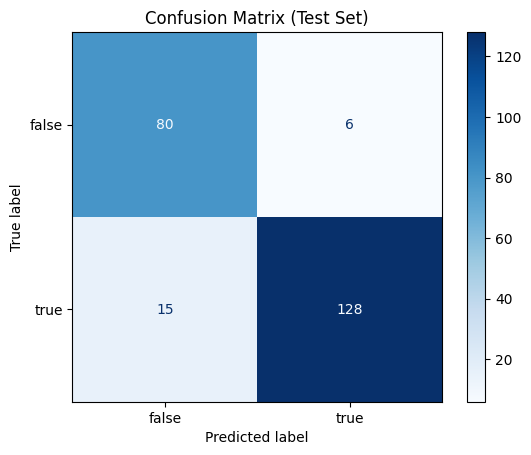


Manual Metrics Calculation (Test Set):
Accuracy: 0.9083
Precision (for 'true'): 0.9552
Recall (Sensitivity for 'true'): 0.8951
Specificity (for 'false'): 0.9302
F1-Score (for 'true'): 0.9242


In [ ]:
# Perform Evaluation (using the test_generator as intended)
true_labels, pred_labels, preds_proba = evaluate_model(model, test_generator)


--- Visualizing Sample Test Predictions (Mixing Classes) ---
Displaying 10 samples from class 'false' and 10 samples from class 'true'.


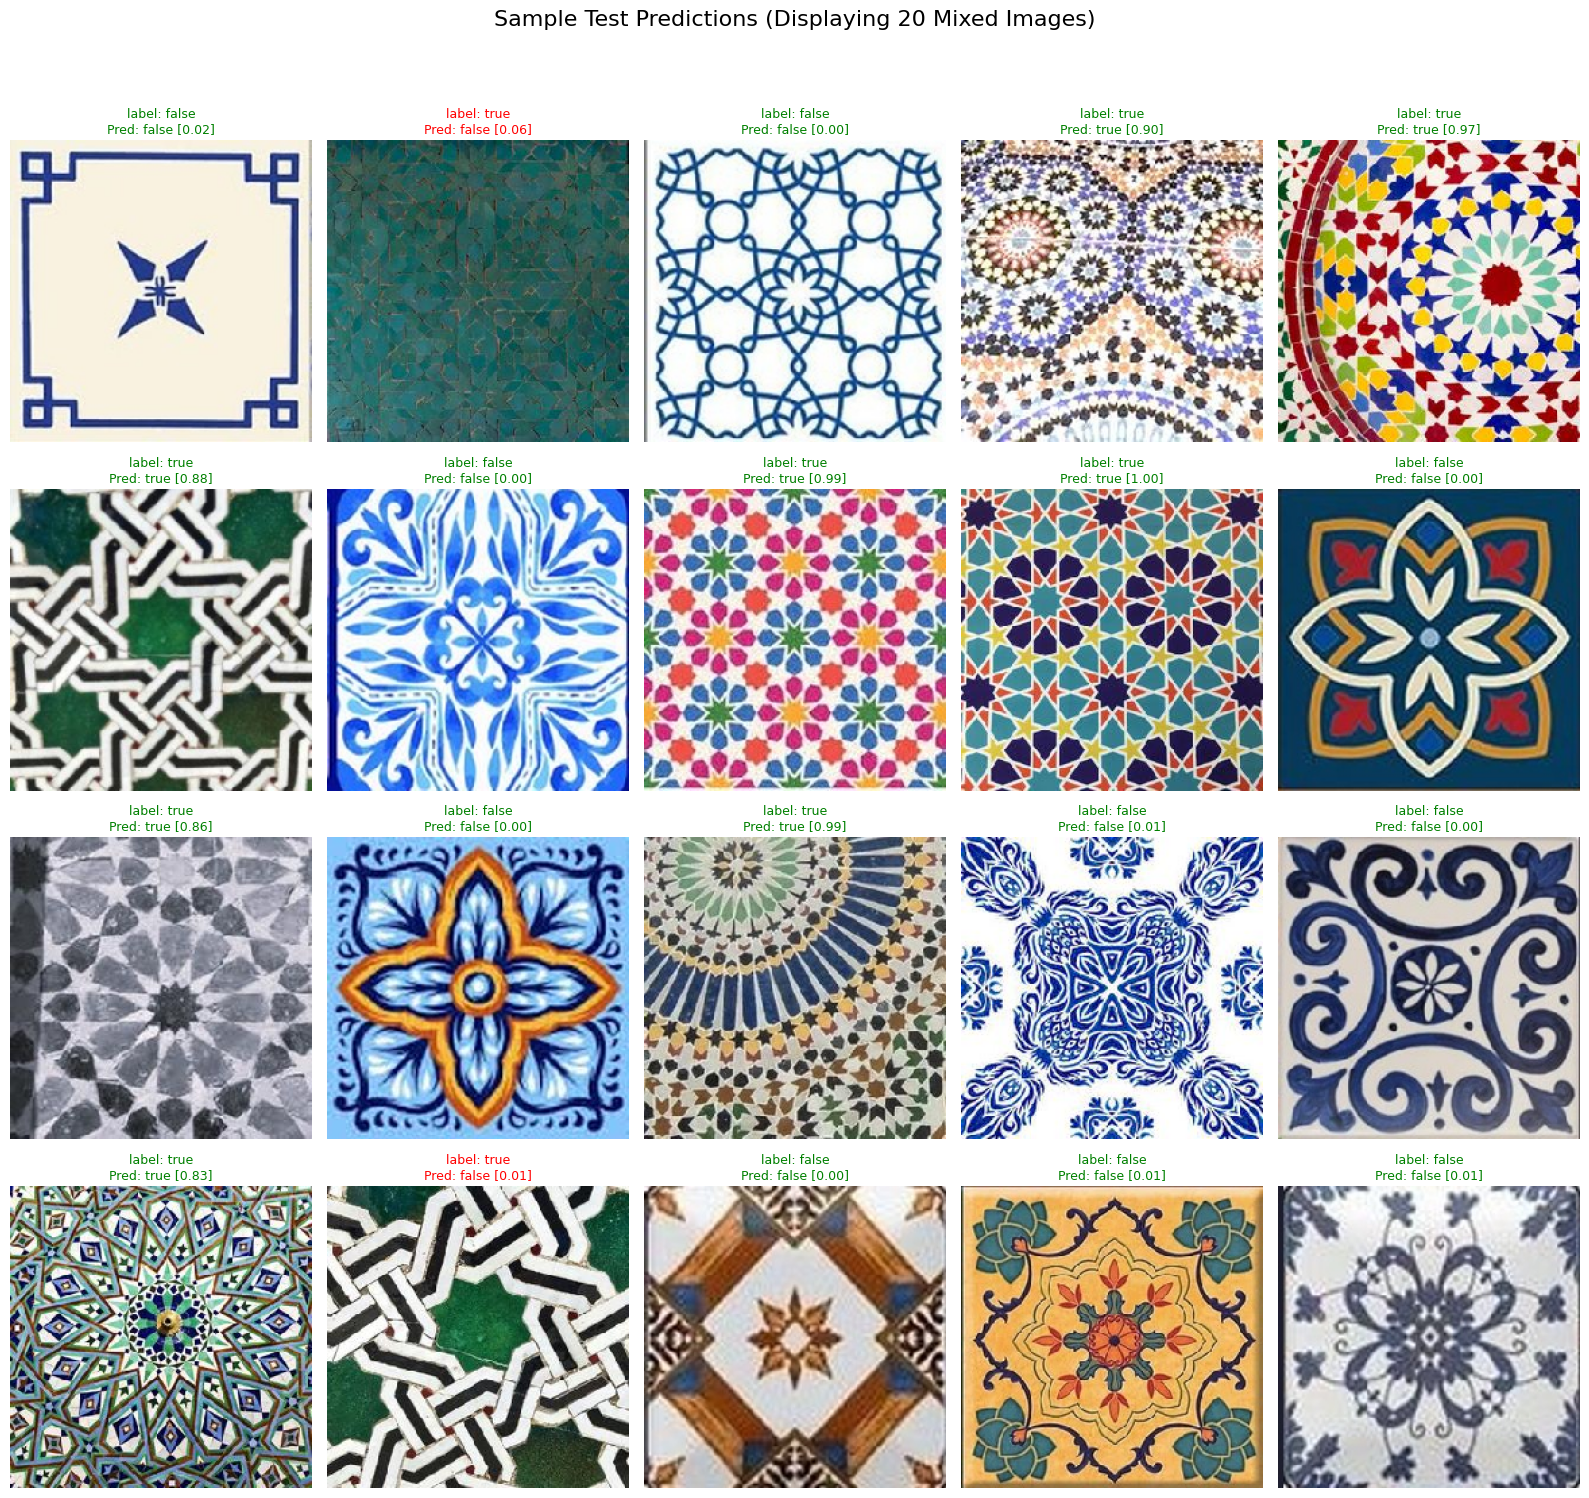


--- Script Finished ---


In [ ]:
# Visualize Predictions vs Labels 
print("\n--- Visualizing Sample Test Predictions (Mixing Classes) ---")
num_display = 20 
test_generator.reset() 


class_names_test = {v: k for k, v in test_generator.class_indices.items()} # Creates {0: 'false', 1: 'true'} or similar


label_class_0 = list(test_generator.class_indices.values())[0] 
label_class_1 = list(test_generator.class_indices.values())[1] 
indices_class_0 = np.where(true_labels == label_class_0)[0]
indices_class_1 = np.where(true_labels == label_class_1)[0]

num_per_class = num_display // 2
num_class_0_to_show = min(num_per_class, len(indices_class_0))
num_class_1_to_show = min(num_display - num_class_0_to_show, len(indices_class_1))
num_class_0_to_show = min(num_display - num_class_1_to_show, len(indices_class_0))


# Select random indices from each class list (True and false)
selected_indices_class_0 = np.random.choice(indices_class_0, num_class_0_to_show, replace=False) if num_class_0_to_show > 0 else []
selected_indices_class_1 = np.random.choice(indices_class_1, num_class_1_to_show, replace=False) if num_class_1_to_show > 0 else []

# Combine the selected indices
indices_to_display = np.concatenate((selected_indices_class_0, selected_indices_class_1)).astype(int)
np.random.shuffle(indices_to_display) # Shuffle to mix them visually

actual_num_displayed = len(indices_to_display)

if actual_num_displayed == 0:
    print("No images found to display based on selected indices.")
else:
    cols = 5
    rows = (actual_num_displayed + cols - 1) // cols
    plt.figure(figsize=(16, 4 * rows))

    print(f"Displaying {num_class_0_to_show} samples from class '{class_names_test[label_class_0]}' and {num_class_1_to_show} samples from class '{class_names_test[label_class_1]}'.")

    for i, index in enumerate(indices_to_display):
        img, _ = test_generator.__getitem__(index) 
        img_array = (img[0] * 255).astype(np.uint8)

        true_label_idx = true_labels[index]
        true_label_name = class_names_test[true_label_idx]
        pred_label_idx = pred_labels[index]
        pred_label_name = class_names_test[pred_label_idx]
        pred_prob = preds_proba[index][0]

        # Display text
        text = f"label: {true_label_name}\nPred: {pred_label_name} [{pred_prob:.2f}]"
        color = 'green' if pred_label_idx == true_label_idx else 'red'

        # Image display 
        img_disp = img_array

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_disp)
        plt.axis('off')
        plt.title(text, fontsize=9, pad=5, color=color)

    plt.suptitle(f"Sample Test Predictions (Displaying {actual_num_displayed} Mixed Images)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("\n--- Script Finished ---")